In [1]:
%load_ext autoreload
%autoreload 2
from utils import *
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM


# Raw task files - Data Exploration

The following file aims to visualize and understand better the task data. 

In [2]:
path = "../object location data/Alle data GOED"
files = sorted(glob.glob(os.path.join(path, "*")))
output_path = "processed_participant_data"

# Process the raw files into data frames which we can work with 
process_folder_raw_data(path, output_path) 

## Error per trial comparison

In [3]:
def compute_trial_type_averages(folder_path):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    dfs = []
    for f in csv_files:
        df = pd.read_csv(f)
        dfs.append(df)

    all_data = pd.concat(dfs, ignore_index=True)
    all_data["trial_type"] = all_data["trial_type"].replace({"DB": "B"})  # Combine B and DB
    all_data = all_data[~all_data["trial_type"].isin(["C", "P"])]    # Exclude C and P trials

    summary = (all_data .groupby("trial_type", as_index=False)
        .agg(
            avg_absolute_error=("sum_absolute_error_distance", "mean"),
            std_absolute_error=("sum_absolute_error_distance", "std"),
            avg_bestfit_error=("sum_bestfit_error_distance", "mean"),
            std_bestfit_error=("sum_bestfit_error_distance", "std"),
            n_trials=("trial_type", "count")
        ).sort_values("trial_type")    )

    return summary

In [4]:
folder_ks = "processed_participant_data/patient/"
folder_hc = "processed_participant_data/controle/"

ks_summary = compute_trial_type_averages(folder_ks)
hc_summary = compute_trial_type_averages(folder_hc)

ks_summary["group"] = "KS"
hc_summary["group"] = "HC"
summary_plot = pd.concat([ks_summary, hc_summary], ignore_index=True)

ks = summary_plot[summary_plot["group"] == "KS"].set_index("trial_type")
hc = summary_plot[summary_plot["group"] == "HC"].set_index("trial_type")
conditions = ["B", "NT", "SimRI", "DivRI", "D"]

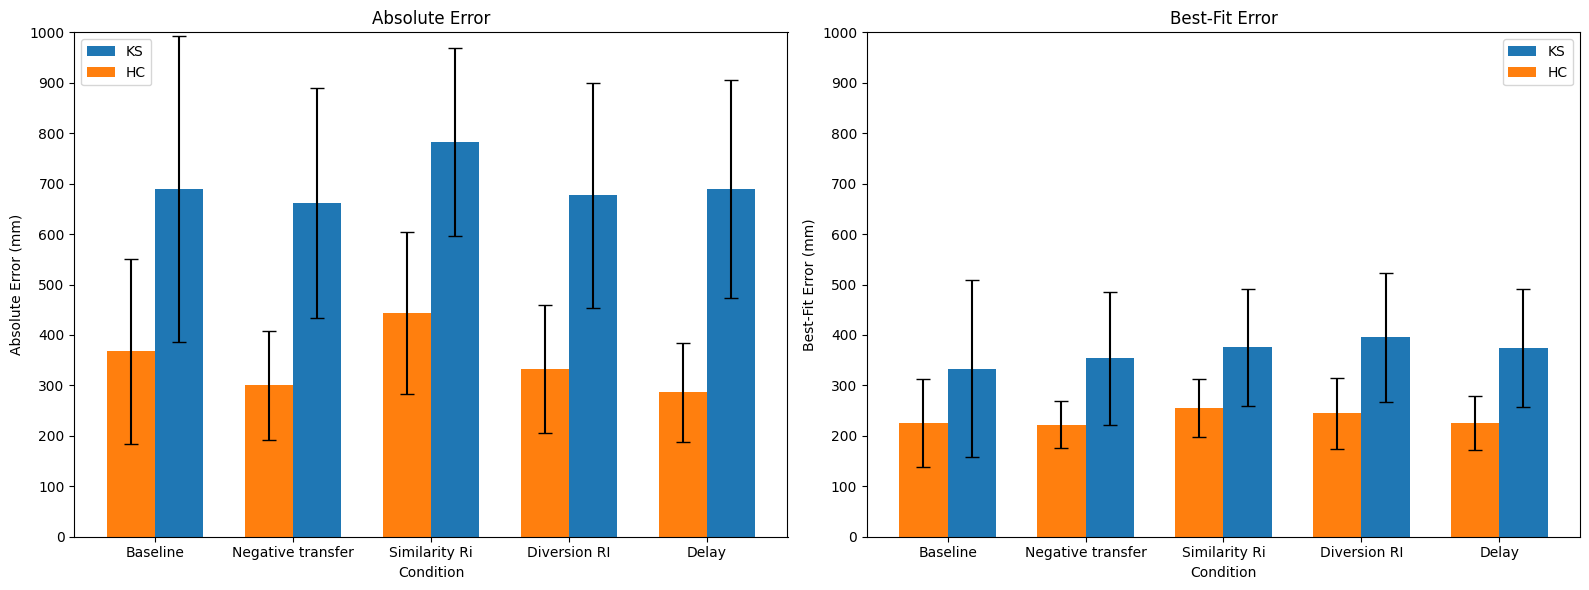

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

y_max = 1000
y_ticks = np.arange(0, y_max + 100, 100)
x = np.arange(len(conditions))
width = 0.35

# Absolute Error
axes[0].bar(x + width/2, ks.loc[conditions, "avg_absolute_error"],
            width, yerr=ks.loc[conditions, "std_absolute_error"], capsize=5, label="KS")
axes[0].bar(x - width/2, hc.loc[conditions, "avg_absolute_error"],
            width, yerr=hc.loc[conditions, "std_absolute_error"], capsize=5, label="HC")
axes[0].set_xticks(x)
axes[1].set_xticklabels(["Baseline", "Negative transfer", "Similarity Ri", "Diversion RI","Delay"])
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Absolute Error (mm)")
axes[0].set_title("Absolute Error")
axes[0].legend()
axes[0].set_ylim(0, y_max)       
axes[0].set_yticks(y_ticks)       

#  Best-Fit Error
axes[1].bar(x + width/2, ks.loc[conditions, "avg_bestfit_error"],
            width, yerr=ks.loc[conditions, "std_bestfit_error"], capsize=5, label="KS")
axes[1].bar(x - width/2, hc.loc[conditions, "avg_bestfit_error"],
            width, yerr=hc.loc[conditions, "std_bestfit_error"], capsize=5, label="HC")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Baseline", "Negative transfer", "Similarity Ri", "Diversion RI","Delay"])
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Best-Fit Error (mm)")
axes[1].set_title("Best-Fit Error")
axes[1].legend()
axes[1].set_ylim(0, y_max)       
axes[1].set_yticks(y_ticks) 

plt.tight_layout()
plt.show()

## ANOVAs

In [22]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Function to load all trial-level data (KS or HC)
def load_trial_data(folder_path, group_name):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    dfs = []
    for f in csv_files:
        df = pd.read_csv(f)
        dfs.append(df)
    all_data = pd.concat(dfs, ignore_index=True)
    
    # Standardize trial types
    #all_data["trial_type"] = all_data["trial_type"].replace({"DB": "B"})
    all_data = all_data[~all_data["trial_type"].isin(["C", "P"])]  # Exclude C and P trials
    
    # Add group column
    all_data["group"] = group_name
    
    # Keep only relevant columns
    return all_data[["trial_type", "sum_absolute_error_distance", "sum_bestfit_error_distance", "group"]].rename(
        columns={
            "sum_absolute_error_distance": "absolute_error",
            "sum_bestfit_error_distance": "bestfit_error"
        }
    )

# Load data
folder_ks = "processed_participant_data/patient/"
folder_hc = "processed_participant_data/controle/"

ks_trials = load_trial_data(folder_ks, "KS")
hc_trials = load_trial_data(folder_hc, "HC")
all_trials = pd.concat([ks_trials, hc_trials], ignore_index=True) # Combine KS and HC
all_trials["trial_type"] = pd.Categorical(all_trials["trial_type"], categories=["B", "NT"], ordered=True)

In [23]:
# --- Two-way ANOVA (Group × Condition (Baseline and NT)) ---
model = ols('absolute_error ~ C(group) + C(trial_type) + C(group):C(trial_type)', data=all_trials).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("Two-way ANOVA for Absolute Error (Baseline vs Negative Transfer):\n")
print(anova_table)

Two-way ANOVA for Absolute Error (Baseline vs Negative Transfer):

                              sum_sq     df           F        PR(>F)
C(group)                7.597644e+06    1.0  136.769606  2.159184e-26
C(trial_type)           4.878504e+04    1.0    0.878208  3.494272e-01
C(group):C(trial_type)  1.927989e+05    1.0    3.470684  6.341723e-02
Residual                1.710961e+07  308.0         NaN           NaN


In [24]:
# --- Two-way ANOVA (Group × Condition (Baseline and NT)) ---
model = ols('bestfit_error ~ C(group) + C(trial_type) + C(group):C(trial_type)', data=all_trials).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("Two-way ANOVA for Best fit Error (Baseline vs Negative Transfer):\n")
print(anova_table)

Two-way ANOVA for Best fit Error (Baseline vs Negative Transfer):

                              sum_sq     df          F        PR(>F)
C(group)                9.695275e+05    1.0  63.416116  3.257171e-14
C(trial_type)           9.267371e+04    1.0   6.061722  1.436176e-02
C(group):C(trial_type)  3.038740e+04    1.0   1.987619  1.595991e-01
Residual                4.708811e+06  308.0        NaN           NaN


## Condition comparision

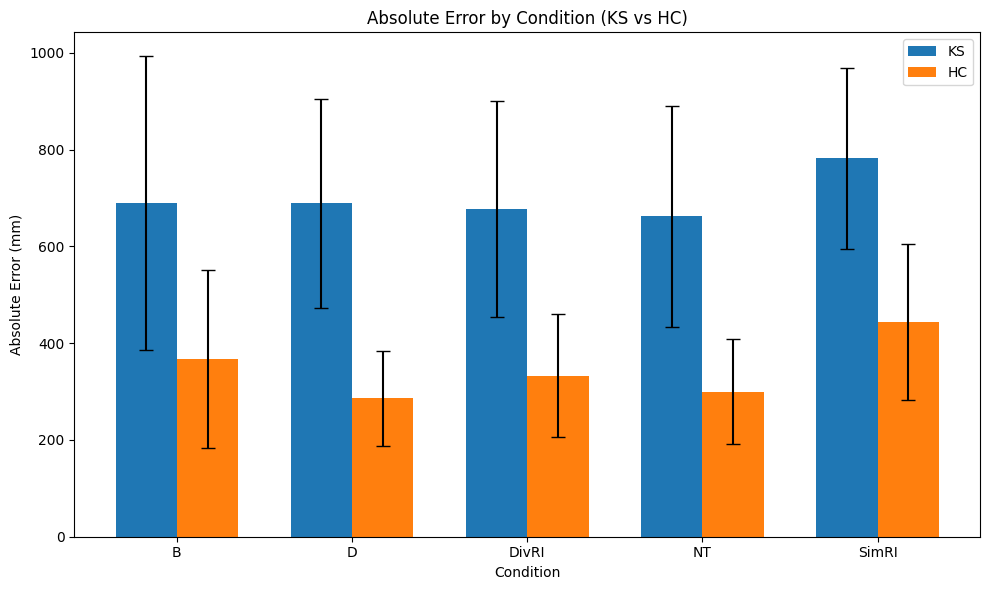

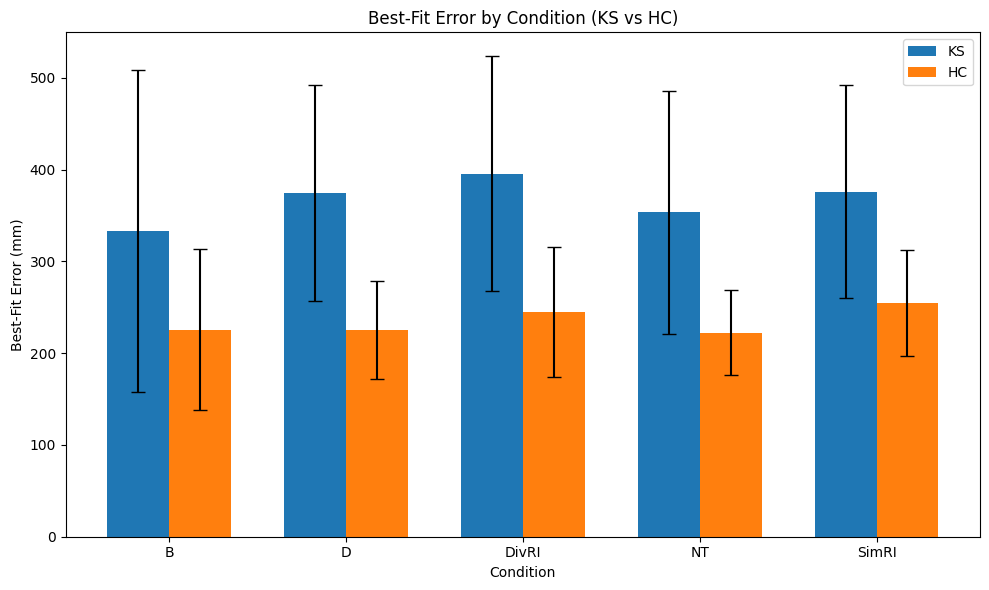

KeyError: 'group'

In [4]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ------------------- Functions -------------------
def compute_trial_type_averages(folder_path):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    dfs = []
    for f in csv_files:
        df = pd.read_csv(f)
        dfs.append(df)

    all_data = pd.concat(dfs, ignore_index=True)
    all_data["trial_type"] = all_data["trial_type"].replace({"DB": "B"})  # Combine B and DB
    all_data = all_data[~all_data["trial_type"].isin(["C", "P"])]          # Exclude C and P

    summary = (all_data.groupby("trial_type", as_index=False)
                     .agg(
                         avg_absolute_error=("sum_absolute_error_distance", "mean"),
                         std_absolute_error=("sum_absolute_error_distance", "std"),
                         avg_bestfit_error=("sum_bestfit_error_distance", "mean"),
                         std_bestfit_error=("sum_bestfit_error_distance", "std"),
                         n_trials=("trial_type", "count")
                     )
                     .sort_values("trial_type"))
    return summary, all_data

# ------------------- Load Data -------------------
folder_ks = "processed_participant_data/patient/"
folder_hc = "processed_participant_data/controle/"

ks_summary, ks_df = compute_trial_type_averages(folder_ks)
hc_summary, hc_df = compute_trial_type_averages(folder_hc)

ks_summary["group"] = "KS"
hc_summary["group"] = "HC"

summary_plot = pd.concat([ks_summary, hc_summary], ignore_index=True)
plot_df = pd.concat([ks_df, hc_df], ignore_index=True)

# ------------------- Plot Bar Graphs -------------------
conditions = sorted(summary_plot["trial_type"].unique())
x = np.arange(len(conditions))
width = 0.35

ks = summary_plot[summary_plot["group"] == "KS"].set_index("trial_type")
hc = summary_plot[summary_plot["group"] == "HC"].set_index("trial_type")

# Absolute Error
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, ks.loc[conditions, "avg_absolute_error"],
        width, yerr=ks.loc[conditions, "std_absolute_error"],
        capsize=5, label="KS")
plt.bar(x + width/2, hc.loc[conditions, "avg_absolute_error"],
        width, yerr=hc.loc[conditions, "std_absolute_error"],
        capsize=5, label="HC")
plt.xticks(x, conditions)
plt.xlabel("Condition")
plt.ylabel("Absolute Error (mm)")
plt.title("Absolute Error by Condition (KS vs HC)")
plt.legend()
plt.tight_layout()
plt.show()

# Best-Fit Error
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, ks.loc[conditions, "avg_bestfit_error"],
        width, yerr=ks.loc[conditions, "std_bestfit_error"],
        capsize=5, label="KS")
plt.bar(x + width/2, hc.loc[conditions, "avg_bestfit_error"],
        width, yerr=hc.loc[conditions, "std_bestfit_error"],
        capsize=5, label="HC")
plt.xticks(x, conditions)
plt.xlabel("Condition")
plt.ylabel("Best-Fit Error (mm)")
plt.title("Best-Fit Error by Condition (KS vs HC)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------- Difference Scores vs Baseline -------------------
# Map condition names
plot_df["condition"] = plot_df["trial_type"].replace({
    "D": "delay",
    "NT": "neg_transfer",
    "SimRI": "similarity_RI",
    "DivRI": "diversion_RI",
    "B": "baseline"
})

# Compute baseline mean per group
baseline_mean = plot_df[plot_df["condition"] == "baseline"].groupby("group")["sum_absolute_error_distance"].mean()
plot_df["baseline_mean"] = plot_df["group"].map(baseline_mean)

# Compute difference from baseline
plot_df["diff_abs"] = plot_df["sum_absolute_error_distance"] - plot_df["baseline_mean"]

# ------------------- One-Sample T-tests -------------------
conditions_to_test = ["neg_transfer", "similarity_RI", "diversion_RI", "delay"]

for group in ["KS", "HC"]:
    print(f"\nGroup: {group}")
    for cond in conditions_to_test:
        data = plot_df[(plot_df["group"] == group) & (plot_df["condition"] == cond)]
        t_stat, p_val = stats.ttest_1samp(data["diff_abs"], 0)
        print(f"{cond}: t = {t_stat:.2f}, p = {p_val:.3f}")
